In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("D:/ML Internship/Mall_Customers_lyst1729241460992.csv")
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [5]:
x=df.iloc[:,2:5].values
x

array([[ 19,  15,  39],
       [ 21,  15,  81],
       [ 20,  16,   6],
       [ 23,  16,  77],
       [ 31,  17,  40],
       [ 22,  17,  76],
       [ 35,  18,   6],
       [ 23,  18,  94],
       [ 64,  19,   3],
       [ 30,  19,  72],
       [ 67,  19,  14],
       [ 35,  19,  99],
       [ 58,  20,  15],
       [ 24,  20,  77],
       [ 37,  20,  13],
       [ 22,  20,  79],
       [ 35,  21,  35],
       [ 20,  21,  66],
       [ 52,  23,  29],
       [ 35,  23,  98],
       [ 35,  24,  35],
       [ 25,  24,  73],
       [ 46,  25,   5],
       [ 31,  25,  73],
       [ 54,  28,  14],
       [ 29,  28,  82],
       [ 45,  28,  32],
       [ 35,  28,  61],
       [ 40,  29,  31],
       [ 23,  29,  87],
       [ 60,  30,   4],
       [ 21,  30,  73],
       [ 53,  33,   4],
       [ 18,  33,  92],
       [ 49,  33,  14],
       [ 21,  33,  81],
       [ 42,  34,  17],
       [ 30,  34,  73],
       [ 36,  37,  26],
       [ 20,  37,  75],
       [ 65,  38,  35],
       [ 24,  38

In [9]:
from sklearn.cluster import KMeans
km=KMeans(n_clusters=7,init="k-means++",random_state=7)
print(km.fit_predict(x))

[3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3
 0 3 0 6 0 6 5 3 5 6 5 5 5 6 5 5 6 6 6 6 6 5 6 6 5 6 6 6 5 6 6 5 5 6 6 6 6
 6 5 2 2 5 2 6 5 6 2 5 2 6 5 5 2 6 5 2 2 2 5 2 5 2 5 5 2 6 5 2 5 6 2 6 6 6
 5 2 5 5 5 6 2 2 2 5 2 2 4 2 4 2 4 1 4 1 4 2 4 1 4 1 4 1 4 1 4 2 4 1 4 2 4
 1 4 1 4 1 4 1 4 1 4 1 4 2 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1
 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4]


D:\AnacondaDistribution\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [11]:
#WCSS Score
wcss=[]
for i in range(1,15):
    kmeans=KMeans(n_clusters=i,init="k-means++",random_state=7)
    kmeans.fit_predict(x)
    wcss.append(kmeans.inertia_)
    print("i=",i,"wcss=",kmeans.inertia_)

i= 1 wcss= 308812.77999999997
i= 2 wcss= 212840.16982097187
i= 3 wcss= 143342.751571706
i= 4 wcss= 104366.15145556201
i= 5 wcss= 75350.77917248776
i= 6 wcss= 58302.40630860367
i= 7 wcss= 54818.938008094054
i= 8 wcss= 48828.055693523085
i= 9 wcss= 45652.62942890442
i= 10 wcss= 38437.595264998425
i= 11 wcss= 35186.89293092186
i= 12 wcss= 34056.077432989005
i= 13 wcss= 31782.869987415255
i= 14 wcss= 30224.476994900524


D:\AnacondaDistribution\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\AnacondaDistribution\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\AnacondaDistribution\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\AnacondaDistribution\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

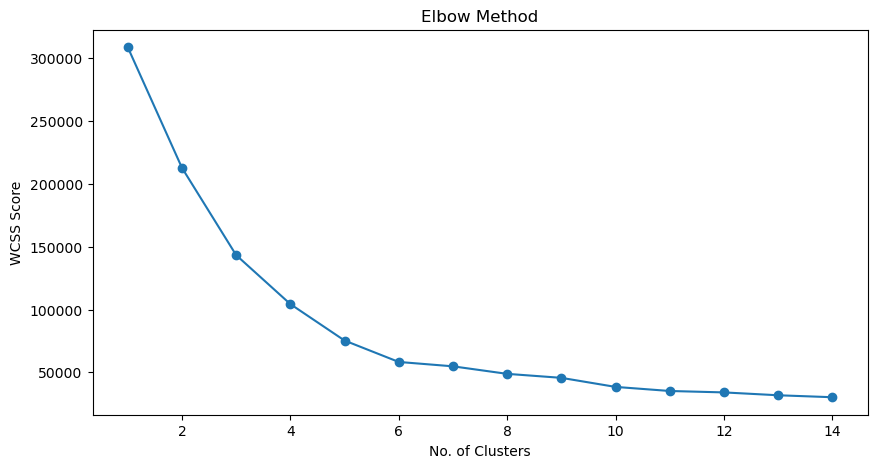

In [17]:
#Creating the elbow curve to decide the optimal value of k
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(range(1,15),wcss,marker="o")
plt.title("Elbow Method")
plt.xlabel("No. of Clusters")
plt.ylabel("WCSS Score")
plt.show()